<a href="https://colab.research.google.com/github/brunopn-code/bank-marketing-propensity/blob/main/notebooks/03_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modeling and Evaluation

This notebook builds classification models to predict whether a client subscribed to a term deposit.

Because the dataset is imbalanced, models will be evaluated using precision, recall, F1-score, ROC-AUC, and confusion matrix instead of accuracy alone.

Two modeling approaches are compared:

1. A model including `duration`, used as a performance upper bound.
2. A realistic model excluding `duration`, used for pre-campaign client targeting.

In [187]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from scipy.stats import chi2_contingency, pointbiserialr, mannwhitneyu
import matplotlib.pyplot as plt
import seaborn as sns

In [157]:
df = pd.read_csv("bank_marketing_clean.csv")

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y,target
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0


In [158]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp_var_rate    41188 non-null  float64
 16  cons_price_idx  41188 non-null  float64
 17  cons_conf_idx   41188 non-null 

In [159]:
X = df.drop(columns=["y", "target"])
y = df["target"]

In [160]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

In [161]:
y_train.value_counts(normalize=True) * 100

,proportion
target,
0,88.734446
1,11.265554


In [162]:
y_test.value_counts(normalize=True) * 100

,proportion
target,
0,88.73513
1,11.26487


In [163]:
categorical_features = X.select_dtypes(include="object").columns.tolist()
categorical_features

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'poutcome']

In [164]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_features

['age',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'emp_var_rate',
 'cons_price_idx',
 'cons_conf_idx',
 'euribor3m',
 'nr_employed']

In [165]:
numeric_features_no_duration = [
    col for col in numeric_features if col != "duration"
]
numeric_features_no_duration

['age',
 'campaign',
 'pdays',
 'previous',
 'emp_var_rate',
 'cons_price_idx',
 'cons_conf_idx',
 'euribor3m',
 'nr_employed']

In [166]:
preprocessor_with_duration = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [167]:
preprocessor_no_duration = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features_no_duration),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

##Dummy Baseline Model
We do this so we can have a baseline to compare our future models

In [168]:
dummy_model = DummyClassifier(strategy="most_frequent")

dummy_model.fit(X_train,y_train)

y_pred_dummy = dummy_model.predict(X_test)

In [169]:
print("Accuracy:", accuracy_score(y_test, y_pred_dummy))
print("Precision:", precision_score(y_test, y_pred_dummy, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_dummy))
print("F1-score:", f1_score(y_test, y_pred_dummy))

Accuracy: 0.8873512988589464
Precision: 0.0
Recall: 0.0
F1-score: 0.0


This baseline achieved high accuracy because the dataset is imbalanced, but it failed completely on the positive class, with precision, recall, and F1-score equal to zero. Confirming that accuracy alone is not appropriate for evaluating this project.

## Logistic Regression Models

Logistic Regression is used as the first real classification model because it is simple, interpretable, and useful as a baseline for comparison with more complex models.

Because the dataset is imbalanced, `class_weight="balanced"` is used to give more importance to the minority class.

In [170]:
def evaluate_model(model_name, y_test, y_pred, y_prob):
  results = {
      "model" : model_name,
      "accuracy" : accuracy_score(y_test, y_pred),
      "precision" : precision_score(y_test, y_pred, zero_division=0),
      "recall" : recall_score(y_test, y_pred),
      "f1-score" : f1_score(y_test, y_pred),
      "roc-auc" : roc_auc_score(y_test, y_prob)
  }

  return results

In [171]:
log_reg_with_duration = Pipeline(
    steps = [
        ("preprocessor", preprocessor_with_duration),
        ("model", LogisticRegression(
            max_iter = 1000,
            class_weight = "balanced",
            random_state = 42
        ))
    ]
)

log_reg_with_duration.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'duration',
                                                   'campaign', 'pdays',
                                                   'previous', 'emp_var_rate',
                                                   'cons_price_idx',
                                                   'cons_conf_idx', 'euribor3m',
                                                   'nr_employed']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [172]:
y_pred_lr_duration = log_reg_with_duration.predict(X_test)
y_prob_lr_duration = log_reg_with_duration.predict_proba(X_test)[:,1]

results_lr_duration = evaluate_model(
    "Logistic Regression with Duration",
    y_test,
    y_pred_lr_duration,
    y_prob_lr_duration
)

results_lr_duration

{'model': 'Logistic Regression with Duration',
 'accuracy': 0.8651371692158291,
 'precision': 0.4512,
 'recall': 0.9116379310344828,
 'f1-score': 0.6036389582590082,
 'roc-auc': np.float64(0.9438378579178264)}

In [173]:
confusion_matrix(y_test, y_pred_lr_duration)

array([[6281, 1029],
       [  82,  846]])

In [174]:
print(classification_report(y_test, y_pred_lr_duration))

              precision    recall  f1-score   support

           0       0.99      0.86      0.92      7310
           1       0.45      0.91      0.60       928

    accuracy                           0.87      8238
   macro avg       0.72      0.89      0.76      8238
weighted avg       0.93      0.87      0.88      8238



In [175]:
log_reg_no_duration = Pipeline(
    steps=[
        ("preprocessor", preprocessor_no_duration),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

log_reg_no_duration.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'campaign', 'pdays',
                                                   'previous', 'emp_var_rate',
                                                   'cons_price_idx',
                                                   'cons_conf_idx', 'euribor3m',
                                                   'nr_employed']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [176]:
y_pred_lr_no_duration = log_reg_no_duration.predict(X_test)
y_proba_lr_no_duration = log_reg_no_duration.predict_proba(X_test)[:, 1]

results_lr_no_duration = evaluate_model(
    "Logistic Regression without duration",
    y_test,
    y_pred_lr_no_duration,
    y_proba_lr_no_duration
)

results_lr_no_duration

{'model': 'Logistic Regression without duration',
 'accuracy': 0.8350327749453751,
 'precision': 0.3678724708767627,
 'recall': 0.646551724137931,
 'f1-score': 0.46893317702227433,
 'roc-auc': np.float64(0.8009417454832776)}

In [177]:
confusion_matrix(y_test, y_pred_lr_no_duration)

array([[6279, 1031],
       [ 328,  600]])

In [178]:
print(classification_report(y_test, y_pred_lr_no_duration))

              precision    recall  f1-score   support

           0       0.95      0.86      0.90      7310
           1       0.37      0.65      0.47       928

    accuracy                           0.84      8238
   macro avg       0.66      0.75      0.69      8238
weighted avg       0.88      0.84      0.85      8238



In [179]:
logistic_results = pd.DataFrame([
    results_lr_duration,
    results_lr_no_duration
])

logistic_results

,model,accuracy,precision,recall,f1-score,roc-auc
0,Logistic Regression with Duration,0.865137,0.451200,0.911638,0.603639,0.943838
1,Logistic Regression without duration,0.835033,0.367872,0.646552,0.468933,0.800942


### Logistic Regression Results

The Logistic Regression model including `duration` performs much better than the model excluding `duration`. It achieves higher recall, F1-score, and ROC-AUC.

However, this result should be interpreted carefully because `duration` is only known after the client has already been contacted. Therefore, the model including `duration` acts as a performance upper bound, but it is not realistic for pre-campaign client targeting.

The Logistic Regression model excluding `duration` is weaker, but it is more realistic for the business problem. It still performs much better than the dummy baseline because it identifies a meaningful number of subscribers instead of always predicting the majority class.


-------

## Statistical Association Analysis

Before training more complex models, we perform statistical association analysis to support the patterns observed during EDA.

This section checks how strongly each variable is associated with the target variable, `target`, where:

* `1` means the client subscribed to a term deposit
* `0` means the client did not subscribe

For categorical variables, we use the chi-square test and Cramér's V.

For numeric variables, we use point-biserial correlation and the Mann-Whitney U test.

Because this dataset is relatively large, p-values may become statistically significant even for small effects. For this reason, the interpretation should focus more on effect size measures such as Cramér's V and correlation strength, not only on p-values.


In [181]:
train_df = X_train.copy()
train_df["target"] = y_train

train_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,target
25611,49,blue-collar,married,basic.9y,unknown,no,no,cellular,nov,wed,...,4,999,0,nonexistent,-0.1,93.200,-42.0,4.120,5195.8,0
26010,37,entrepreneur,married,university.degree,no,no,no,telephone,nov,wed,...,2,999,1,failure,-0.1,93.200,-42.0,4.120,5195.8,0
40194,78,retired,married,basic.4y,no,no,no,cellular,jul,mon,...,1,999,0,nonexistent,-1.7,94.215,-40.3,0.870,4991.6,1
297,36,admin.,married,university.degree,no,yes,no,telephone,may,mon,...,2,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
36344,59,retired,divorced,university.degree,no,no,no,cellular,jun,tue,...,2,999,0,nonexistent,-2.9,92.963,-40.8,1.262,5076.2,0


### Categorical Association Analysis

For categorical variables, we use the chi-square test to check whether the distribution of subscription outcomes differs across categories.

We also calculate Cramér's V, which measures the strength of association between each categorical feature and the target variable.

Cramér's V ranges from 0 to 1:

* values near 0 indicate weak association
* higher values indicate stronger association


In [183]:
def cramers_v(contingency_table):
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape

    return np.sqrt((chi2 / n) / min(k - 1, r - 1))

In [184]:
categorical_association_results = []

for col in categorical_features:
    contingency_table = pd.crosstab(train_df[col], train_df["target"])

    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    cv = cramers_v(contingency_table)

    categorical_association_results.append({
        "feature": col,
        "chi2_statistic": chi2,
        "p_value": p_value,
        "cramers_v": cv
    })

categorical_association_df = (
    pd.DataFrame(categorical_association_results)
    .sort_values("cramers_v", ascending=False)
    .reset_index(drop=True)
)

categorical_association_df

,feature,chi2_statistic,p_value,cramers_v
0,poutcome,3384.732687,0.000000e+00,0.320505
1,month,2458.782516,0.000000e+00,0.273170
2,job,756.330358,4.475532e-155,0.151505
3,contact,675.098190,7.778686e-149,0.143138
4,default,323.885542,4.668187e-71,0.099144
5,education,165.703165,2.019915e-32,0.070915
6,marital,110.260620,9.643782e-24,0.057847
7,day_of_week,12.890707,1.182235e-02,0.019779
8,housing,3.181591,2.037634e-01,0.009826
9,loan,0.009170,9.954257e-01,0.000528


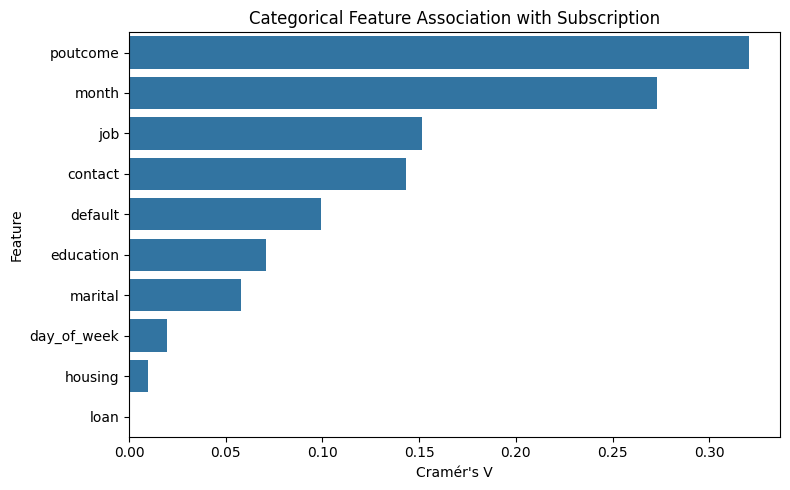

In [188]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=categorical_association_df,
    x="cramers_v",
    y="feature"
)
plt.title("Categorical Feature Association with Subscription")
plt.xlabel("Cramér's V")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("stat_categorical_association_cramers_v.png", dpi=300, bbox_inches="tight")
plt.show()

### Numeric Association Analysis

For numeric variables, we use point-biserial correlation because the target variable is binary.

This measures whether higher or lower values of each numeric feature are associated with subscription.

Positive values indicate that higher feature values are associated with subscription. Negative values indicate that lower feature values are associated with subscription.


In [189]:
numeric_association_results = []

for col in numeric_features:
    corr, p_value = pointbiserialr(train_df[col], train_df["target"])

    numeric_association_results.append({
        "feature": col,
        "point_biserial_correlation": corr,
        "p_value": p_value
    })

numeric_association_df = (
    pd.DataFrame(numeric_association_results)
    .sort_values(
        "point_biserial_correlation",
        key=lambda x: abs(x),
        ascending=False
    )
    .reset_index(drop=True)
)

numeric_association_df

,feature,point_biserial_correlation,p_value
0,duration,0.400752,0.000000e+00
1,nr_employed,-0.349729,0.000000e+00
2,pdays,-0.325539,0.000000e+00
3,euribor3m,-0.303174,0.000000e+00
4,emp_var_rate,-0.293690,0.000000e+00
5,previous,0.229759,0.000000e+00
6,cons_price_idx,-0.132520,5.723661e-129
7,campaign,-0.065462,1.256583e-32
8,cons_conf_idx,0.055327,9.155033e-24
9,age,0.028673,1.933636e-07


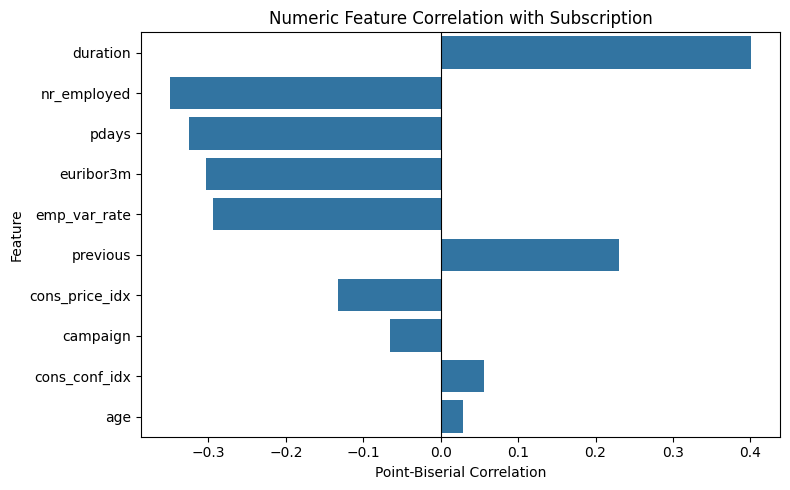

In [190]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=numeric_association_df,
    x="point_biserial_correlation",
    y="feature"
)
plt.title("Numeric Feature Correlation with Subscription")
plt.xlabel("Point-Biserial Correlation")
plt.ylabel("Feature")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("stat_numeric_association_point_biserial.png", dpi=300, bbox_inches="tight")
plt.show()

In [191]:
mannwhitney_results = []

for col in numeric_features:
    group_no = train_df.loc[train_df["target"] == 0, col]
    group_yes = train_df.loc[train_df["target"] == 1, col]

    statistic, p_value = mannwhitneyu(
        group_no,
        group_yes,
        alternative="two-sided"
    )

    mannwhitney_results.append({
        "feature": col,
        "mannwhitney_statistic": statistic,
        "p_value": p_value,
        "median_no": group_no.median(),
        "median_yes": group_yes.median()
    })

mannwhitney_df = (
    pd.DataFrame(mannwhitney_results)
    .sort_values("p_value")
    .reset_index(drop=True)
)

mannwhitney_df

,feature,mannwhitney_statistic,p_value,median_no,median_yes
0,duration,19822288.5,0.000000e+00,164.000,448.000
1,pdays,64839345.5,0.000000e+00,999.000,999.000
2,emp_var_rate,77362732.5,0.000000e+00,1.100,-1.800
3,euribor3m,80294528.0,0.000000e+00,4.857,1.266
4,nr_employed,80829252.5,0.000000e+00,5195.800,5099.100
5,previous,42275074.0,1.172024e-295,0.000,0.000
6,cons_price_idx,65917288.5,7.185829e-103,93.918,93.200
7,campaign,59981617.5,2.862154e-28,2.000,2.000
8,cons_conf_idx,50118218.5,1.775277e-14,-41.800,-40.400
9,age,55552629.0,1.834699e-02,38.000,37.000


### Statistical Association Findings

The statistical association analysis supports the patterns observed during EDA.

Among categorical variables, `poutcome` shows the strongest association with subscription, followed by `month`, `job`, and `contact`. This confirms that previous campaign outcome, campaign timing, client occupation, and contact channel are important variables for understanding subscription behavior.

Among numeric variables, `duration` shows the strongest positive association with subscription. However, this variable is a data leakage risk because it is only known after the call has occurred. Therefore, it should not be used in the final realistic pre-campaign targeting model.

The economic variables `nr_employed`, `euribor3m`, and `emp_var_rate` show strong negative associations with subscription. This suggests that clients were more likely to subscribe during certain economic conditions.

The variable `pdays` also shows a strong association, but it must be interpreted carefully because the value `999` means the client was not previously contacted. For this reason, feature engineering should create a clearer variable indicating whether the client had previous campaign contact.

The Mann-Whitney U test confirms that several numeric variables have statistically different distributions between subscribers and non-subscribers. However, because the dataset is large, p-values are often very small. Therefore, interpretation should focus more on effect size, business meaning, and model performance than on p-values alone.

Overall, the strongest variables identified before model comparison are:

* `duration`
* `poutcome`
* `month`
* `job`
* `contact`
* `nr_employed`
* `pdays`
* `euribor3m`
* `emp_var_rate`
* `previous`


-------

## Feature Engineering

Based on the EDA and statistical association analysis, we create a few additional features to make some variables easier for models to use and easier for business interpretation.

The main engineered features are:

- `previously_contacted`: whether the client was contacted in a previous campaign
- `pdays_clean`: a cleaner version of `pdays`, where the special value `999` is replaced
- `age_group`: age grouped into business-interpretable categories
- `campaign_group`: number of contacts grouped into campaign intensity categories

The variable `duration` is not transformed here because it is a leakage variable. It will be kept only for the upper-bound model and excluded from the realistic targeting model.